# Micro proyecto No. 2

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("datos_ods.csv") 
print(df.shape)
print(df.info())

(9656, 2)
<class 'pandas.DataFrame'>
RangeIndex: 9656 entries, 0 to 9655
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   textos  9656 non-null   str  
 1   ODS     9656 non-null   int64
dtypes: int64(1), str(1)
memory usage: 151.0 KB
None


In [5]:
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


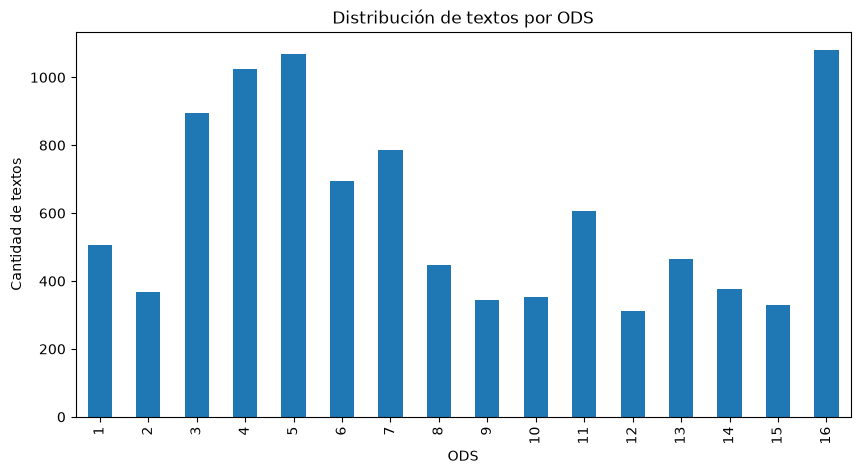

In [7]:
ods_count = df["ODS"].value_counts().sort_index()

ods_count.plot(kind="bar", figsize=(10,5))
plt.title("Distribución de textos por ODS")
plt.xlabel("ODS")
plt.ylabel("Cantidad de textos")
plt.show()

In [14]:
df["textos"].str.split().str.len().describe()

count    9656.000000
mean      111.017295
std        37.082212
min        24.000000
25%        82.000000
50%       105.000000
75%       135.000000
max       268.000000
Name: textos, dtype: float64

In [15]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)  # quitar números y signos, conservar tildes/ñ
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df["texto_limpio"] = df["textos"].apply(limpiar_texto) 

In [16]:
df["texto_limpio"].head()

0    aprendizaje y educación se consideran sinónimo...
1    no dejar clara la naturaleza de estos riesgos ...
2    como resultado un mayor y mejorado acceso al a...
3    con el congreso firmemente en control de la ju...
4    luego dos secciones finales analizan las impli...
Name: texto_limpio, dtype: str

In [21]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["texto_limpio"],
    df["ODS"],
    test_size=0.2,
    random_state=42,
    stratify=df["ODS"] #Mantiene la proporcion de clases para hacer la division de test train
)

print(X_train_text.shape, X_test_text.shape)

(7724,) (1932,)


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stopwords_es = stopwords.words('spanish')

vectorizador = TfidfVectorizer(
    stop_words=stopwords_es,
    ngram_range=(1, 2),      # unigramas + bigramas, dado que los textos son cortos
    min_df=3,                # ignora términos casi únicos (ruido)
    max_df=0.9,               # ignora términos casi omnipresentes
    max_features=8000,        # controla dimensionalidad
    sublinear_tf=True          # aplica log(1+tf), suaviza textos con repeticiones
)

X_train_tfidf = vectorizador.fit_transform(X_train_text)
X_test_tfidf = vectorizador.transform(X_test_text)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(7724, 8000)
(1932, 8000)


['abajo' 'abajo hacia' 'abandonan' 'abandonar' 'abandono' 'abarca'
 'abarcan' 'abastecimiento' 'abastecimiento agua' 'abierta' 'abiertas'
 'abierto' 'abiertos' 'aboga' 'abogados' 'aborda' 'abordado' 'abordan'
 'abordando' 'abordar']
8000
